In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_csv("Salary_Data (1).csv")

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000
YearsExperience    0
Salary             0
dtype: int64
(30, 2)


In [4]:
print(df.corr())

                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


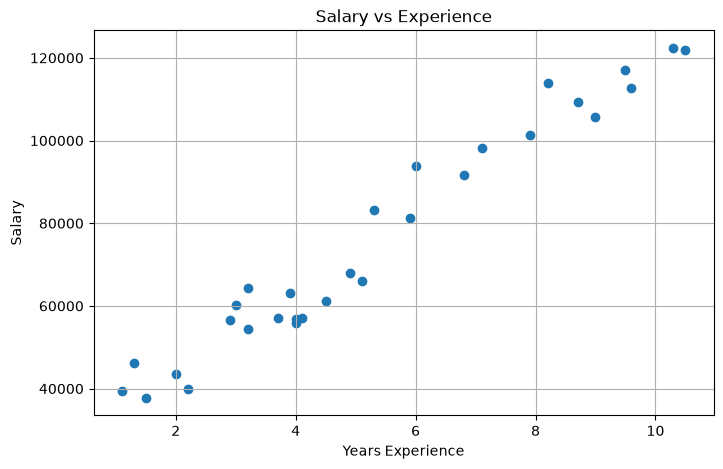

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["YearsExperience"],df["Salary"])
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.grid(True)
plt.show()

In [7]:
X=df[["YearsExperience"]]

y=df["Salary"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model=LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
print("Slope =",model.coef_[0])

print("Intercept =",model.intercept_)

Slope = 9423.815323030976
Intercept = 25321.583011776813


In [10]:
y_pred=model.predict(X_test)

In [11]:
print("MAE =",mean_absolute_error(y_test,y_pred))

print("MSE =",mean_squared_error(y_test,y_pred))

print("RMSE =",np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2 Score =",r2_score(y_test,y_pred))

MAE = 6286.453830757749
MSE = 49830096.85590839
RMSE = 7059.04362190151
R2 Score = 0.9024461774180497


In [12]:
result=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

print(result)

      Actual      Predicted
27  112635.0  115790.210113
15   67938.0   71498.278095
23  113812.0  102596.868661
17   83088.0   75267.804224
8    64445.0   55477.792045
9    57189.0   60189.699707


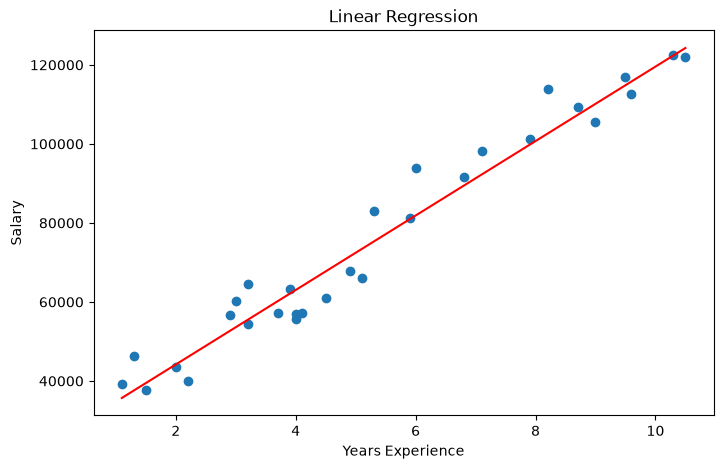

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(df["YearsExperience"],df["Salary"])

plt.plot(
    df["YearsExperience"],
    model.predict(df[["YearsExperience"]]),
    color="red"
)

plt.xlabel("Years Experience")
plt.ylabel("Salary")

plt.title("Linear Regression")

plt.show()